# Stage 1: data and cleaning (DECISIONS D001-D012)

Display only. Run `make all` first; this notebook reads `reports/`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from src.config import load_config

cfg = load_config()
T, F = cfg["paths"]["tables"], cfg["paths"]["figures"]
pd.set_option("display.width", 200)


def show(name):
    plt.figure(figsize=(12, 5))
    plt.imshow(mpimg.imread(F / name))
    plt.axis("off")
    plt.show()

In [2]:
pd.read_csv(T / "data_source.csv")

,file,source,casdatasets_version,documented_period,retrieved,rows,idpol_raw_unique_labels,idpol_parsed_unique,sha256,url
0,freMTPL2freq,"CASdatasets (dutangc/CASdatasets, master branch)",1.2-1,The period is approximately 2011-2013.,2026-10-03,677991,677991,677991,82c8598513d9fa78226b6c7d271a9940eca4b8083e9e32...,https://raw.githubusercontent.com/dutangc/CASd...
1,freMTPL2sev,"CASdatasets (dutangc/CASdatasets, master branch)",1.2-1,The period is approximately 2011-2013.,2026-10-03,26444,24944,24944,78e6e5016ae046603b37e88ff8ad8ca327f5d59f827c1f...,https://raw.githubusercontent.com/dutangc/CASd...


In [3]:
pd.read_csv(T / "cleaning_log.csv")

,step,policies_affected,exposure_affected,claims_affected
0,recount ClaimNb from sev,0,0.00,0
1,cap Exposure at 1.0,1224,139.34,54
2,cap ClaimNb at 4 (frequency only),8,0.00,39


In [4]:
pd.read_csv(T / "data_summary.csv")

,dataset,policies,exposure,claims,frequency,claim_amount,mean_severity
0,raw,677991,358482.835463,26444.0,0.073766,59909216.50,2265.512649
1,cleaned (all),677991,358343.495463,26405.0,0.073686,59909216.50,2265.512649
2,learn,541840,286514.750107,21056.0,0.073490,45216079.76,2145.891498
3,holdout,136151,71828.745356,5349.0,0.074469,14693136.74,2734.624370


In [5]:
pd.read_csv(T / "split_balance.csv")

,fold,policies,groups,exposure,claims,frequency,share_of_policies
0,holdout,136151,105923,71828.745356,5349,0.074469,0.200815
1,fold_0,108354,84565,57363.588435,4263,0.074315,0.159816
2,fold_1,108500,84565,57115.168651,4129,0.072293,0.160032
3,fold_2,108582,84564,57240.414635,4241,0.074091,0.160153
4,fold_3,107898,84564,57319.078223,4272,0.074530,0.159144
5,fold_4,108506,84564,57476.500163,4151,0.072221,0.160040


In [6]:
pd.read_csv(T / "severity_tail_thresholds.csv")

,threshold,quantile_of_claims,claims_above,share_claims_above,share_amount_from_claims_above,share_amount_in_excess,large_load_on_capped,mean_excess,attritional_mean,attritional_mean_cv_across_folds,load_min_across_folds,load_max_across_folds,load_cv_across_folds
0,5000,0.952589,999,0.047411,0.487660,0.377191,0.605628,17072.159309,1336.481069,0.017378,0.375655,0.779658,0.301146
1,10000,0.981586,388,0.018414,0.392464,0.306654,0.442281,35736.278660,1487.846027,0.026358,0.235489,0.601086,0.357979
2,20000,0.991932,170,0.008068,0.326631,0.251436,0.335891,66876.181176,1606.337096,0.031642,0.158462,0.496856,0.426260
3,30000,0.994495,116,0.005505,0.297800,0.220836,0.283428,86080.676724,1672.000439,0.039834,0.131654,0.450059,0.469839
4,50000,0.996868,66,0.003132,0.255181,0.182198,0.222789,124822.223636,1754.914954,0.056373,0.102004,0.399381,0.548338
5,100000,0.998624,29,0.001376,0.199875,0.135739,0.157057,211640.215862,1854.611243,0.077870,0.065393,0.354615,0.755891
6,200000,0.999193,17,0.000807,0.159656,0.084461,0.092253,224647.809412,1964.646528,0.100424,0.024038,0.298242,1.234640


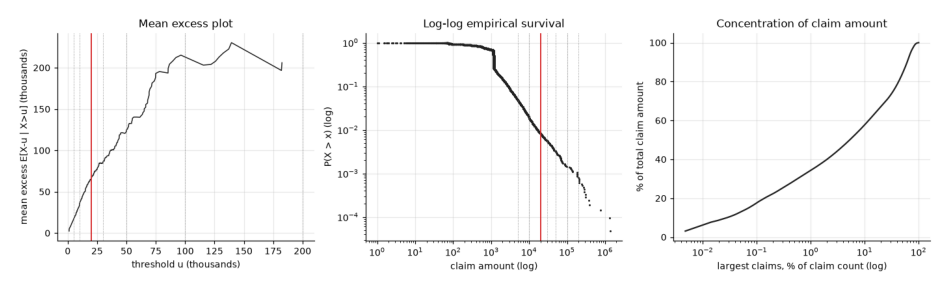

In [7]:
show("severity_tail.png")